##### Feladat (Példatár 1.23)

Egy kör keresztmetszetű tömör alumínium tengely két vége be van fogva, a terhelése az ábrán látható. Az anyagtulajdonságok ismertek: $E = 70 ~\mathrm{GPa}$, $\nu = 0.34$. Határozzuk meg a reakciónyomatékokat! Méretezzük a tengelyt ha $\tau_\mathrm{meg} = 100 ~\mathrm{MPa}$! Mekkora a $C$ keresztmetszet $A$-hoz képesti elcsavarodási szöge?

<img src="img/01.jpg" alt="Feladat" width=300px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
F = 3 # kN
E = 70 # GPa
nu = 0.34
tau_meg = 100 # MPa
L_1 = 400 # mm
L_2 = 600 # mm
L_3 = 50 # mm

# Átváltás N, mm, MPa rendszerbe
F = F * 10**3 # N
E = E * 10**3 # MPa

##### Reakciónyomatékok meghatározása

<img src="img/02.jpg" alt="Feladat" width=250px>

In [3]:
# Csavarónyomaték meghatározása
M = F*2*L_3
display(Math(rf'M = {latex(M)} ~\mathrm{{Nmm}}'))

<IPython.core.display.Math object>

In [4]:
M_A, M_B, I_p, G = sp.symbols('M_A, M_B, I_p, G')

# Csavarónyomatéki egyensúly
eq1 = M_A + M + M_B

# Alakváltozási feltétel
phi_1 = M_A * L_1 / (I_p * G)
phi_2 = (M_A + M) * L_2 / (I_p * G)

eq2 = phi_1 + phi_2

# Rendszer megoldása
sol = sp.solve([eq1, eq2], (M_A, M_B))
M_Asol = sol[M_A]
M_Bsol = sol[M_B]

display(Math(rf'M_A = {latex(M_Asol)} ~\mathrm{{Nmm}}'))
display(Math(rf'M_B = {latex(M_Bsol)} ~\mathrm{{Nmm}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Csavaró igénybevétel

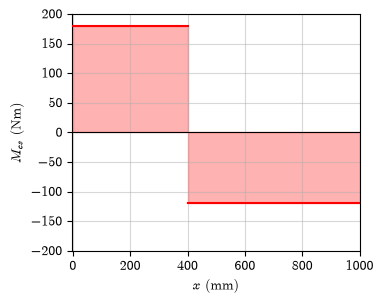

In [5]:
M_cs1 = -float(M_Asol)
M_cs2 = -float(M_Asol) - float(M)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot([0, float(L_1)], [M_cs1*1e-3, M_cs1*1e-3], color='red', zorder=5)
plt.fill_between([0, float(L_1)], [M_cs1 * 1e-3, M_cs1 * 1e-3], 0, color='red', alpha=0.3)
plt.plot([float(L_1), float(L_1+L_2)], [M_cs2*1e-3, M_cs2*1e-3], color='red', zorder=5)
plt.fill_between([float(L_1), float(L_1+L_2)], [M_cs2 * 1e-3, M_cs2 * 1e-3], 0, color='red', alpha=0.3)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel(r'$x ~ \mathrm{(mm)}$')
plt.ylabel(r'$M_{cs} ~ \mathrm{(Nm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-2, L_1+L_2)
plt.ylim(-200, 200)
plt.tight_layout()
plt.savefig('csavaronyomateki_igenybevetel.pdf')
plt.show()

In [6]:
# Maximális csavarónyomaték
M_csmax = sp.Max(sp.Abs(M_cs1), sp.Abs(M_cs2))
display(Math(rf'M_{{cs,max}} = {latex(M_csmax)} ~\mathrm{{Nmm}}'))

<IPython.core.display.Math object>

##### Méretezés

In [7]:
# Poláris keresztmetszeti tényező
d = sp.Symbol('d')
K_p = d**3*sp.pi/16

# Ébredő feszültség
tau_max = M_csmax / K_p

# Határhelyzet
eq = tau_max - tau_meg
sol = sp.solve(eq, d)
dsol = sol[0]
display(Math(rf'd = {latex(round(dsol, 3))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

##### $C$ keresztmetszet elcsavarodása az $A$-hoz képest

In [8]:
# Poláris másodrendű nyomaték
I_p = dsol**4*sp.pi/32
display(Math(rf'I_p = {latex(round(I_p, 3))} ~ \mathrm{{mm^4}}'))

# Csúsztató rugalmassági modulusz
G = E / (2*(1+nu))
display(Math(rf'G = {latex(round(G, 3))} ~ \mathrm{{MPa}}'))

# Keresztmetszet elcsavarodása
phi_C = sp.Abs(M_Asol) * L_1 / (I_p * G)
phi_C = sp.deg(phi_C)
display(Math(rf'\varphi_C = {latex(phi_C.evalf(4))}^\circ'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>